Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 102ms/step - accuracy: 0.9271 - loss: 0.2455 - val_accuracy: 0.9833 - val_loss: 0.0600
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9797 - loss: 0.0675 - val_accuracy: 0.9885 - val_loss: 0.0417
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.9855 - loss: 0.0483 - val_accuracy: 0.9897 - val_loss: 0.0363


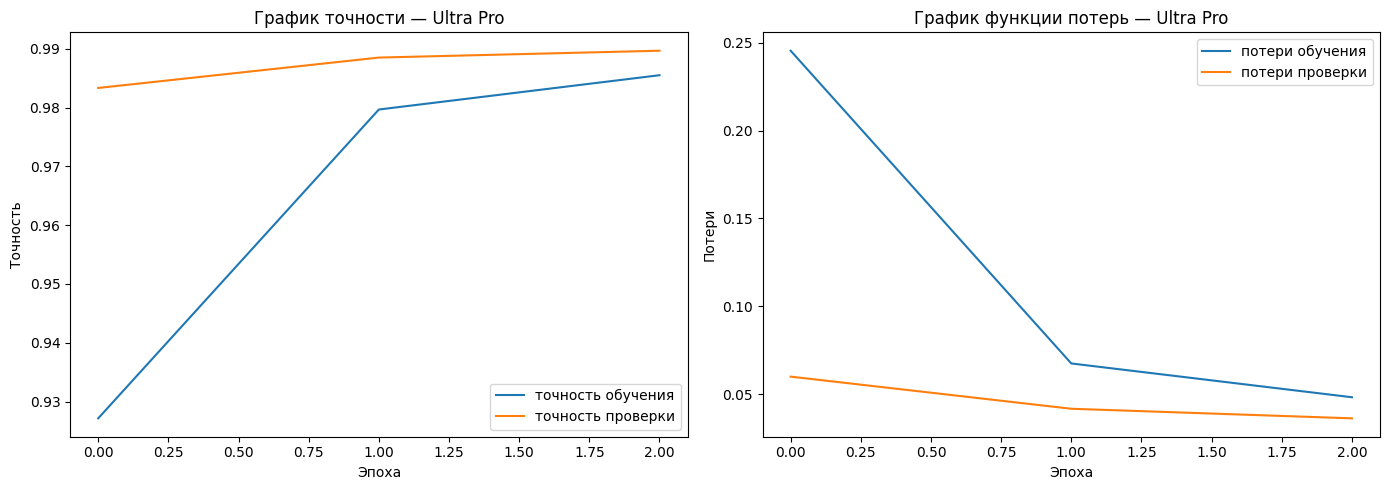

Веса сохранены в ultra.weights.h5
Точность на MNIST (тест): 0.9904000163078308


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import files

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Функция для построения графиков точности и функции потерь
def plot_training_graphs(history, title=''):
    title_suffix = f' — {title}' if title else ''

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    if 'accuracy' in history.history:
        plt.plot(history.history['accuracy'], label='точность обучения')
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='точность проверки')
    plt.title('График точности' + title_suffix)
    plt.xlabel('Эпоха')
    plt.ylabel('Точность')
    plt.legend()

    plt.subplot(1, 2, 2)
    if 'loss' in history.history:
        plt.plot(history.history['loss'], label='потери обучения')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='потери проверки')
    plt.title('График функции потерь' + title_suffix)
    plt.xlabel('Эпоха')
    plt.ylabel('Потери')
    plt.legend()

    plt.tight_layout()
    plt.show()


(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = (x_train.astype("float32") / 255.0)[..., None]
x_test  = (x_test.astype("float32") / 255.0)[..., None]

model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])

model.compile(optimizer=Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(x_train, y_train, epochs=3, batch_size=128, validation_split=0.1, verbose=1)

plot_training_graphs(history, "Ultra Pro")

# Сохранение весов
model.save_weights('ultra.weights.h5')
print("Веса сохранены в ultra.weights.h5")

loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Точность на MNIST (тест):", acc)

In [5]:

import cv2
from scipy.ndimage import center_of_mass, shift

def preprocess_paint_png(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("Файл не прочитан. Проверьте имя/путь.")

    # сглаживание
    img = cv2.GaussianBlur(img, (3,3), 0)

    # авто-инверсия
    if img.mean() > 127:
        img = 255 - img

    _, bw = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # ищем рамку цифры
    coords = cv2.findNonZero(bw)
    if coords is None:
        raise ValueError("На изображении не найдено пикселей цифры (после порога).")

    x, y, w, h = cv2.boundingRect(coords)
    digit = bw[y:y+h, x:x+w]

    # делаем квадрат с полем
    size = max(w, h) + 8
    square = np.zeros((size, size), dtype=np.uint8)
    x_off = (size - w) // 2
    y_off = (size - h) // 2
    square[y_off:y_off+h, x_off:x_off+w] = digit

    resized = cv2.resize(square, (20,20), interpolation=cv2.INTER_AREA)
    padded = np.pad(resized, ((4,4),(4,4)), mode="constant")

    cy, cx = center_of_mass(padded)
    if np.isnan(cx) or np.isnan(cy):
        raise ValueError("Проблема с центром масс (пустое изображение после обработки).")

    shift_y = 14 - cy
    shift_x = 14 - cx
    centered = shift(padded, shift=(shift_y, shift_x), order=0, mode="constant", cval=0)

    # нормирование
    x_in = (centered.astype("float32") / 255.0).reshape(1, 28, 28, 1)

    return x_in, centered

Saving 8.png to 8.png
Файл: 8.png


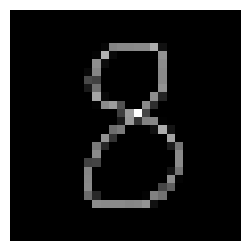

Распознано: 8
Уверенность: 0.3480306565761566
Вероятности по классам:
0 : 0.047296192497015
1 : 0.04079223424196243
2 : 0.07299629598855972
3 : 0.18143050372600555
4 : 0.028462188318371773
5 : 0.13275830447673798
6 : 0.047469429671764374
7 : 0.04145772382616997
8 : 0.3480306565761566
9 : 0.059306465089321136


In [6]:
uploaded = files.upload()
fname = list(uploaded.keys())[0]
print("Файл:", fname)

x_in, dbg = preprocess_paint_png(fname)

# показываем, что реально подаётся в сеть
plt.figure(figsize=(3,3))
plt.imshow(dbg, cmap="gray")
plt.axis("off")
plt.show()

pred = model.predict(x_in, verbose=0)[0]
digit = int(np.argmax(pred))
conf = float(np.max(pred))

print("Распознано:", digit)
print("Уверенность:", conf)

print("Вероятности по классам:")
for i, p in enumerate(pred):
    print(i, ":", float(p))